### DEMO3: Overview of using fusion model Bimodal Deep AutoEncoder ([BDAE](https://link.springer.com/chapter/10.1007/978-3-319-46672-9_58)) to train the real dataset ([BBBD](https://bbbd.pythonanywhere.com/))(The Brain, Body, and Behaviour Dataset), using SVM/PCA/TSNE to evaluate the results, and do the bootstrap to estimate perforrmance stabiliy.

##### Pipeline
1. Load BBBD **EEG** + **Gaze** data and labels. (one fusion case)
2. Preprocess both modalities with **sliding-window Differential Entropy (DE)** features.
3. Add different levels' noise to the original data.
4. Train a **Bimodal Deep AutoEncoder (BDAE)** to learn a fused latent representation.
5. Evaluate representations using **Linear SVM** and visualize with **PCA / t-SNE** + heatmap.
6. Bootstrap stability: repeat subsampling + training to estimate performance stability.

In [12]:
import os
import gc
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

from scipy.stats import differential_entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats

cm2inch = 1.0 / 2.54

### 1 & 2. Load and preprocessing data：

In [13]:
# ——— Config ———
sfreq     = 128.0
win_sec   = 4.0
step_sec  = 1.0
win_samp  = int(win_sec  * sfreq)
step_samp = int(step_sec * sfreq)

def compute_de_sliding(signal, window_size, step):
    n = len(signal)
    starts = np.arange(0, n - window_size + 1, step)
    de_vals = np.array([
        differential_entropy(signal[st:st + window_size])
        for st in starts
    ], dtype=np.float32)
    return de_vals, starts

##### EEG preprocessing：

We load EEG `.bdf` data for two sessions and compute DE features:
- `ses-01` → label 0
- `ses-02` → label 1

Output format:
- EEG DE matrix: (n_channels, total_windows)
- Labels: (total_windows,)

In [14]:
# load raw data
base_dir = '../dataset/raw_bbbd/sub-04'
sessions = {'ses-01': 0, 'ses-02': 1}

eeg_de_list = []
eeg_label_list = []

for ses, lbl in sessions.items():
    path = os.path.join(base_dir, ses, 'eeg', f'sub-04_{ses}_task-stim01_desc-eeg.bdf')
    raw = mne.io.read_raw_bdf(path, preload=True, stim_channel=None, verbose=False)
    data = raw.get_data()  # (n_chan, n_times)

    de_mats = []
    for ch in range(data.shape[0]):
        de_vals, starts = compute_de_sliding(data[ch], win_samp, step_samp)
        de_mats.append(de_vals)

    de_mat = np.vstack(de_mats)  # (n_chan, n_windows)
    de_mat = de_mat[:, :-1]
    eeg_de_list.append(de_mat)
    eeg_label_list.append(np.full(de_mat.shape[1], lbl, dtype=np.int32))

    print(f"{ses}: EEG DE shape = {de_mat.shape}")

eeg_de = np.concatenate(eeg_de_list, axis=1)       # (n_chan, total_windows)
eeg_labels = np.concatenate(eeg_label_list, axis=0) # (total_windows,)

print("Merged EEG DE:", eeg_de.shape)
print("Merged EEG labels:", eeg_labels.shape)

d:\Anaconda3\envs\bdae\lib\site-packages\scipy\stats\_entropy.py:316: RuntimeWarning: divide by zero encountered in log
  logs = np.log(n * differences / (ci * m))


ses-01: EEG DE shape = (64, 258)
ses-02: EEG DE shape = (64, 258)
Merged EEG DE: (64, 516)
Merged EEG labels: (516,)


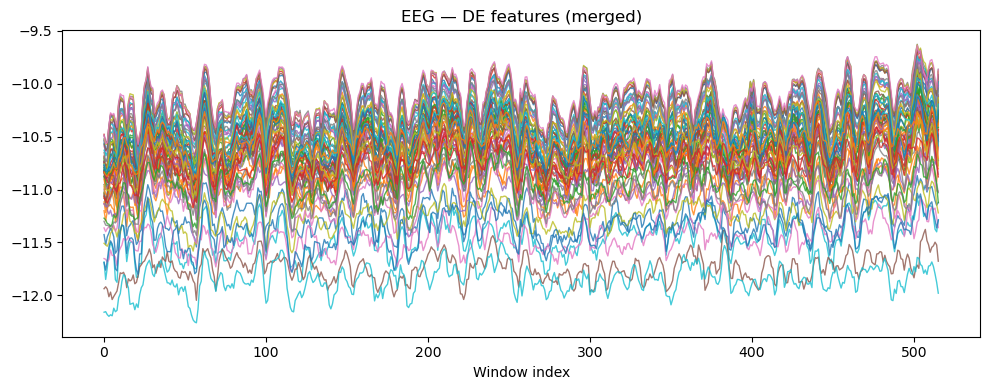

In [15]:
# visualization for eeg
plt.figure(figsize=(10, 4))
for ch in range(eeg_de.shape[0]):
    plt.plot(eeg_de[ch], alpha=0.8, linewidth=1.0)
plt.title("EEG — DE features (merged)")
plt.xlabel("Window index")
plt.tight_layout()
plt.show()

##### Gaze preprocessing (BBBD)

We load gaze eyetrack `.tsv` for two sessions and compute DE per channel, using the same windowing.

Output:
- Gaze DE matrix: (n_gaze_channels, total_windows)
- Labels aligned with EEG labels by session concatenation

In [16]:
# load raw data
subject = 'sub-04'
root_dir = '../dataset/raw_bbbd'
session_list = ['ses-01', 'ses-02']
label_map = {'ses-01': 0, 'ses-02': 1}
suf = 'desc-gaze_visualangle_eyetrack'

In [17]:
gaze_de_list = []
gaze_label_list = []

for ses in session_list:
    beh_dir = os.path.join(root_dir, subject, ses, 'eyetrack')
    fname = next(
        f for f in os.listdir(beh_dir)
        if f.startswith(f"{subject}_{ses}_task-stim01_{suf}") and f.endswith('.tsv')
    )
    path = os.path.join(beh_dir, fname)
    df = pd.read_csv(path, sep='\t', header=None)
    data = df.values.T  # (n_chan, n_times)

    de_mats = []
    for ch in range(data.shape[0]):
        de_vals, starts = compute_de_sliding(data[ch], win_samp, step_samp)
        de_mats.append(de_vals)

    de_mat = np.vstack(de_mats)  # (n_chan, n_windows)
    gaze_de_list.append(de_mat)
    gaze_label_list.append(np.full(de_mat.shape[1], label_map[ses], dtype=np.int32))

    print(f"{ses}: Gaze DE shape = {de_mat.shape}")

gaze_de = np.concatenate(gaze_de_list, axis=1)
gaze_labels = np.concatenate(gaze_label_list, axis=0)

print("Merged Gaze DE:", gaze_de.shape)
print("Merged Gaze labels:", gaze_labels.shape)

ses-01: Gaze DE shape = (4, 258)
ses-02: Gaze DE shape = (4, 258)
Merged Gaze DE: (4, 516)
Merged Gaze labels: (516,)


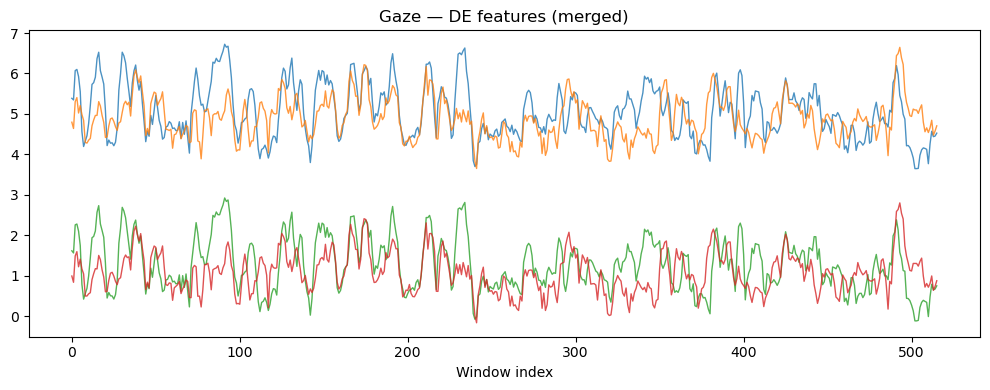

In [18]:
# visualization for gaze
plt.figure(figsize=(10, 4))
for ch in range(gaze_de.shape[0]):
    plt.plot(gaze_de[ch], alpha=0.8, linewidth=1.0)
plt.title("Gaze — DE features (merged)")
plt.xlabel("Window index")
plt.tight_layout()
plt.show()

### 3. Add noise for EEG data and Gaze data, we add Gaussian noise to test robustness. Original noise level is [0, 0.1, 0.2, 0.3, 0.4, 0.5], but for demo we just use 0.1.

In [19]:
labels = eeg_labels

noise_sigma = 0.1
noisy_eeg = eeg_de + np.random.normal(0.0, noise_sigma, size=eeg_de.shape)
noisy_gaze = gaze_de + np.random.normal(0.0, noise_sigma, size=gaze_de.shape)

print("Noisy EEG:", noisy_eeg.shape, "Noisy Gaze:", noisy_gaze.shape)
print("Labels:", labels.shape, "unique:", np.unique(labels))

Noisy EEG: (64, 516) Noisy Gaze: (4, 516)
Labels: (516,) unique: [0 1]


### 4. Train BDAE (fast mode)

We treat:
- EEG as the neural modality
- Gaze as the behavior modality

In [20]:
from sklearn.preprocessing import MinMaxScaler

neural_data = noisy_eeg.T      # (n_windows, 64)
behavior_data = noisy_gaze.T   # (n_windows, 4)

scaler_n = MinMaxScaler()
scaler_b = MinMaxScaler()

neural_data = scaler_n.fit_transform(neural_data)
behavior_data = scaler_b.fit_transform(behavior_data)

X_all = np.hstack([neural_data, behavior_data])

X_temp, X_test, y_temp, labels_test = train_test_split(
    X_all, labels,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=labels
)

X_train, X_val, labels_train, labels_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    shuffle=True,
    stratify=y_temp
)

n = neural_data.shape[1]
neural_train, behavior_train = X_train[:, :n], X_train[:, n:]
neural_val,   behavior_val   = X_val[:, :n],   X_val[:, n:]
neural_test,  behavior_test  = X_test[:, :n],  X_test[:, n:]

print("Train:", neural_train.shape, behavior_train.shape)
print("Val:",   neural_val.shape,   behavior_val.shape)
print("Test:",  neural_test.shape,  behavior_test.shape)

Train: (309, 64) (309, 4)
Val: (103, 64) (103, 4)
Test: (104, 64) (104, 4)


This part is similar as demo2.

In [21]:
import tensorflow as tf
from keras import backend as K
from keras.layers import Dense, Input, Concatenate, Lambda, Dropout
from keras.models import Model
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping
from sklearn.neural_network import BernoulliRBM

from keras.backend.tensorflow_backend import set_session
config = tf.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.Session(config=config)
set_session(sess)

# BBBD data (516, 64) (516, 4) 
# for demo we choose one hp
# batch_sizes = [50]
# n_iter_list = [20, 50]
# hidden_units_list = [10, 20, 30, 40, 50, 70, 90, 110, 130]
# epochs_list = [1000, 700, 500, 250, 100, 50, 10]
# learning_rate_list = [0.01]

batch_sizes = [50]
n_iter_list = [20]
hidden_units_list = [10]
epochs_list = [10]
learning_rate_list = [0.01]

# train BDAE
for this_bs in batch_sizes:
    bdae_transformed_dir = f'./bdae_bbbd_fusion_noise0.1_fm_bs{this_bs}/'
    if not os.path.exists(bdae_transformed_dir):
        os.mkdir(bdae_transformed_dir)

    for this_niter in n_iter_list:
        for this_hidden in hidden_units_list:
            for this_epoch in epochs_list:
                for this_lr in learning_rate_list:
                    print("\n========================================")
                    print(f"Training BDAE | batch_size={this_bs} | "
                          f"n_iter={this_niter} | hidden_units={this_hidden} | "
                          f"epochs={this_epoch} | lr={this_lr}")
                    print("========================================\n")

                    rbm1 = BernoulliRBM(n_components=this_hidden, batch_size=this_bs, n_iter=this_niter, learning_rate=this_lr, random_state=42)
                    rbm2 = BernoulliRBM(n_components=this_hidden, batch_size=this_bs, n_iter=this_niter, learning_rate=this_lr, random_state=42)
                    rbm3 = BernoulliRBM(n_components=this_hidden, batch_size=this_bs, n_iter=this_niter, learning_rate=this_lr, random_state=42)

                    print('Training RBM 1 (Neural Data)')
                    rbm1.fit(neural_train)
                    hidden_neural = rbm1.transform(neural_train)
                    weights_neural = rbm1.components_

                    print('Training RBM 2 (Behavior Data)')
                    rbm2.fit(behavior_train)
                    hidden_behavior = rbm2.transform(behavior_train)
                    weights_behavior = rbm2.components_

                    print('Training RBM 3 (Fusion)')
                    concat_data = np.append(hidden_neural, hidden_behavior, axis=1)
                    rbm3.fit(concat_data)
                    weights_merge = rbm3.components_

                    def get_neural_part(nparray): 
                        return nparray[:, :this_hidden]

                    def get_behavior_part(nparray):
                        return nparray[:, this_hidden:]

                    print('Building Model...')
                    x_input = Input(shape=(neural_data.shape[1],), name='x_input')
                    y_input = Input(shape=(behavior_data.shape[1],), name='y_input')

                    x_hidden = Dense(this_hidden, weights=[weights_neural.T, rbm1.intercept_hidden_], activation='sigmoid', name='x_hidden')(x_input)
                    y_hidden = Dense(this_hidden, weights=[weights_behavior.T, rbm2.intercept_hidden_], activation='sigmoid', name='y_hidden')(y_input)

                    merge_xy = Concatenate()([x_hidden, y_hidden])
                    feature_layer = Dense(this_hidden, weights=[weights_merge.T, rbm3.intercept_hidden_], activation='sigmoid', name='merged')(merge_xy)
                    feature_layer = Dropout(0.2)(feature_layer)

                    merge_xy_t = Dense(2 * this_hidden, weights=[weights_merge, rbm3.intercept_visible_], activation='sigmoid', name='merge_t')(feature_layer)
                    x_hidden_t = Lambda(get_neural_part, output_shape=(this_hidden,))(merge_xy_t)
                    y_hidden_t = Lambda(get_behavior_part, output_shape=(this_hidden,))(merge_xy_t)

                    x_recon = Dense(neural_data.shape[1], weights=[weights_neural, rbm1.intercept_visible_], activation='sigmoid', name='x_recon')(x_hidden_t)
                    y_recon = Dense(behavior_data.shape[1], weights=[weights_behavior, rbm2.intercept_visible_], activation='sigmoid', name='y_recon')(y_hidden_t)

                    model = Model(inputs=[x_input, y_input], outputs=[x_recon, y_recon])
                    model.compile(optimizer=RMSprop(lr=this_lr), loss='mean_squared_error')

                    early_stop = EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True)

                    print(f'Training model with {this_epoch} epochs, batch_size={this_bs}')
                    history = model.fit(
                        [neural_train, behavior_train], [neural_train, behavior_train],
                        validation_data=([neural_val, behavior_val], [neural_val, behavior_val]),
                        epochs=this_epoch, batch_size=this_bs, verbose=1, callbacks=[early_stop]
                    )

                    # save loss
                    plt.figure()
                    plt.plot(history.history['loss'], label='Train Loss')
                    if 'val_loss' in history.history:
                        plt.plot(history.history['val_loss'], label='Val Loss')
                    plt.title(f"Loss Curve - n_iter={this_niter}, hidden={this_hidden}, epochs={this_epoch}, lr={this_lr}, bs={this_bs}")
                    plt.xlabel("Epoch")
                    plt.ylabel("Loss (MSE)")
                    plt.legend()
                    loss_plot_filename = f"loss_{this_niter}_{this_hidden}_{this_epoch}_{this_lr}.png"
                    plt.savefig(os.path.join(bdae_transformed_dir, loss_plot_filename))
                    plt.close()

                    # capture train and test features
                    print('Extracting Features...')
                    feature_res = K.function([model.input[0], model.input[1]], [model.get_layer("merged").output])
                    train_features = feature_res([neural_train, behavior_train])[0]
                    val_features   = feature_res([neural_val, behavior_val])[0]
                    test_features  = feature_res([neural_test, behavior_test])[0]

                    feature_filename = f'features_{this_niter}_{this_hidden}_{this_epoch}_{this_lr}.pkl'
                    feature_path = os.path.join(bdae_transformed_dir, feature_filename)
                    with open(feature_path, 'wb') as f:
                        pickle.dump({
                            "train_features": train_features,
                            "train_labels":   labels_train,
                            "val_features":   val_features,
                            "val_labels":     labels_val,
                            "test_features":  test_features,
                            "test_labels":    labels_test
                        }, f)

                    weights_filename = f"weights_{this_niter}_{this_hidden}_{this_epoch}_{this_lr}.h5"
                    weights_path = os.path.join(bdae_transformed_dir, weights_filename)
                    model.save_weights(weights_path)
                    print(f"Saved model weights to: {weights_path}")

print("All Training Complete!")

Using TensorFlow backend.





Training BDAE | batch_size=50 | n_iter=20 | hidden_units=10 | epochs=10 | lr=0.01

Training RBM 1 (Neural Data)
Training RBM 2 (Behavior Data)
Training RBM 3 (Fusion)
Building Model...








Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.

Training model with 10 epochs, batch_size=50


Train on 309 samples, validate on 103 samples
Epoch 1/10
309/309 [==============================] - 0s 862us/step - loss: 0.0784 - x_recon_loss: 0.0386 - y_recon_loss: 0.0398 - val_loss: 0.0678 - val_x_recon_loss: 0.0351 - val_y_recon_loss: 0.0327
Epoch 2/10
309/309 [==============================] - 0s 38us/step - loss: 0.0696 - x_recon_loss: 0.0328 - y_recon_loss: 0.0368 - val_loss: 0.0663 - val_x_recon_loss: 0.0336 - val_y_recon_loss: 0.0326
Epoch 3/10
309/309 [==============================] - 0s 45us/step - loss: 0.0676 - x_recon_loss: 0.0312 - y_recon_loss: 0.0364 - val_loss: 0.0656 - val_x_recon_loss: 0.0332 - val_y_recon_loss

### 5. Evaluate fused representation

Similar as demo2, we extract the `merged` layer as fused features, then:
- Train Linear SVM on train+val
- Test on test set
- Visualize with PCA / t-SNE (2D/3D) and heatmap

In [22]:
# Load data
def prepare_split_result(file_path):
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    result = {"file": os.path.basename(file_path)}
    for split in ['train', 'val', 'test']:
        if f"{split}_features" in data and f"{split}_labels" in data:
            result[f"{split}_features"] = np.array(data[f"{split}_features"])
            result[f"{split}_labels"] = np.array(data[f"{split}_labels"])
    return result

In [23]:
# SVM
def evaluate_svm(train_X, train_y, val_X, val_y, test_X, test_y):
    X_tr = np.vstack([train_X, val_X])
    y_tr = np.concatenate([train_y, val_y])

    pipe = make_pipeline(
        StandardScaler(),
        LinearSVC(C=1.0, max_iter=10000, dual=False, random_state=42)
    )

    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(test_X)

    acc = accuracy_score(test_y, y_pred)
    f1 = f1_score(test_y, y_pred, average='weighted')
    cm = confusion_matrix(test_y, y_pred)
    
    return acc, f1, cm

In [24]:
# Visualization PCA / t-SNE (2D / 3D)
def visualize_dim_reduction(X, y, method='pca', dims=2, split_name='train'):
    assert method in ['pca', 'tsne']
    assert dims in [2, 3]

    if method == 'pca':
        model = PCA(n_components=dims, random_state=0)
        X_proj = model.fit_transform(X)
    else:
        model = TSNE(n_components=dims, random_state=0, init='pca')
        X_proj = model.fit_transform(X)

    fig = plt.figure(figsize=(18 * cm2inch, 12.4 * cm2inch))

    if dims == 3:
        ax = fig.add_subplot(111, projection='3d')
        for label in np.unique(y):
            pts = X_proj[y == label]
            ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=18, label=f"Label {int(label)+1}")
        ax.set_title(f"{split_name.upper()} - {method.upper()} 3D")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.set_zlabel("Dim 3")
    else:
        ax = fig.add_subplot(111)
        for label in np.unique(y):
            pts = X_proj[y == label]
            ax.scatter(pts[:, 0], pts[:, 1], s=18, label=f"Label {int(label)+1}")
        ax.set_title(f"{split_name.upper()} - {method.upper()} 2D")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")

    ax.grid(True)
    ax.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Visualization Heatmap visualization
def visualize_heatmap(train_X, train_y, test_X, test_y):
    X_combined = np.concatenate([train_X, test_X], axis=0)
    y_combined = np.concatenate([train_y, test_y], axis=0)

    sort_idx = np.argsort(y_combined)
    X_sorted = X_combined[sort_idx]
    y_sorted = y_combined[sort_idx]

    fig = plt.figure(figsize=(18 * cm2inch, 12.4 * cm2inch))
    ax = fig.add_subplot(111)

    sns.heatmap(X_sorted, cmap='viridis', yticklabels=False, ax=ax)

    changes = np.where(np.diff(y_sorted) != 0)[0] + 1
    for c in changes:
        ax.hlines(c, *ax.get_xlim(), colors='k', linewidth=0.5)

    ax.set_title("Heatmap (Train + Test, sorted by label)")
    ax.set_xlabel("Feature dimension")
    ax.set_ylabel("Samples (sorted)")
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [25]:
# Main
pkl_folder = './bdae_bbbd_fusion_noise0.1_bs50'
linear_results = []

for filename in os.listdir(pkl_folder):
    if filename.endswith(".pkl"):
        file_path = os.path.join(pkl_folder, filename)
        result = prepare_split_result(file_path)

        X_train = np.concatenate([
            result["train_features"],
            result.get("val_features", np.empty((0, result["train_features"].shape[1])))
        ], axis=0)
        y_train = np.concatenate([
            result["train_labels"],
            result.get("val_labels", np.empty((0,), dtype=result["train_labels"].dtype))
        ], axis=0)
        X_test = result["test_features"]
        y_test = result["test_labels"]

        # SVM
        acc, f1, cm = evaluate_svm(
            result["train_features"], result["train_labels"],
            result.get("val_features", np.empty((0, result["train_features"].shape[1]))),
            result.get("val_labels", np.empty((0,), dtype=result["train_labels"].dtype)),
            X_test, y_test
        )

        result.update({
            "train_features": X_train,
            "train_labels": y_train,
            "test_features": X_test,
            "test_labels": y_test,
            "svm_accuracy": acc,
            "svm_f1_score": f1,
            "confusion_matrix": cm
        })
        linear_results.append(result)

best_result = max(linear_results, key=lambda x: x["svm_accuracy"])
file_id = best_result["file"].replace(".pkl", "")

print(f"\nBest Linear SVM Accuracy File: {file_id}")
print(f"  Accuracy: {best_result['svm_accuracy']:.4f}")
print(f"  F1 Score: {best_result['svm_f1_score']:.4f}")
print("  Confusion Matrix:")
print(best_result["confusion_matrix"])


Best Linear SVM Accuracy File: features_50_110_1000_0.01
  Accuracy: 0.7115
  F1 Score: 0.7106
  Confusion Matrix:
[[34 18]
 [12 40]]


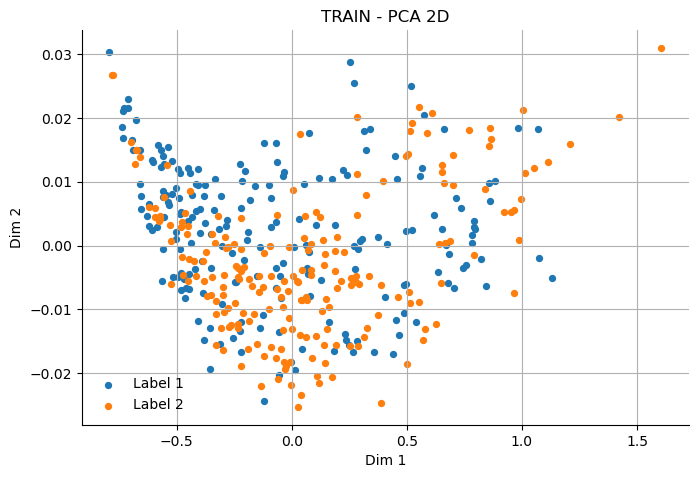

d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


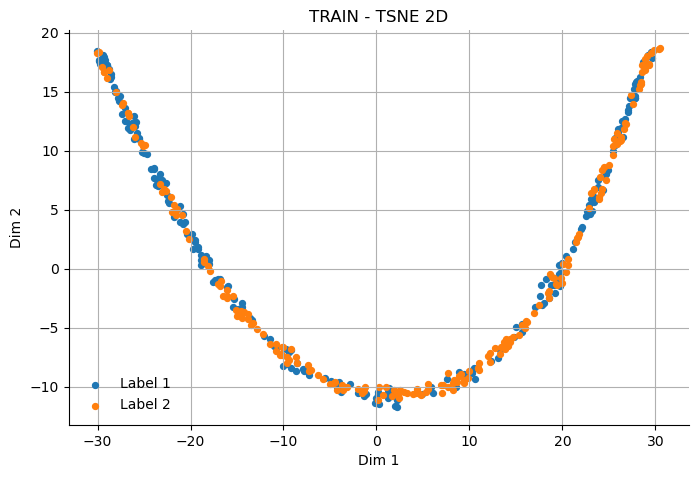

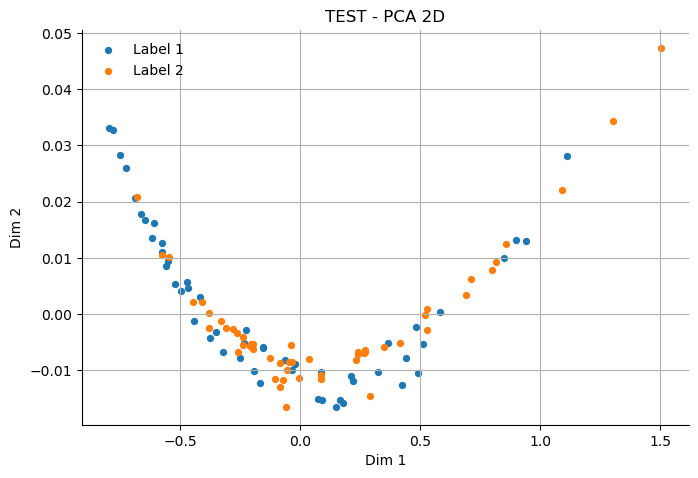

d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


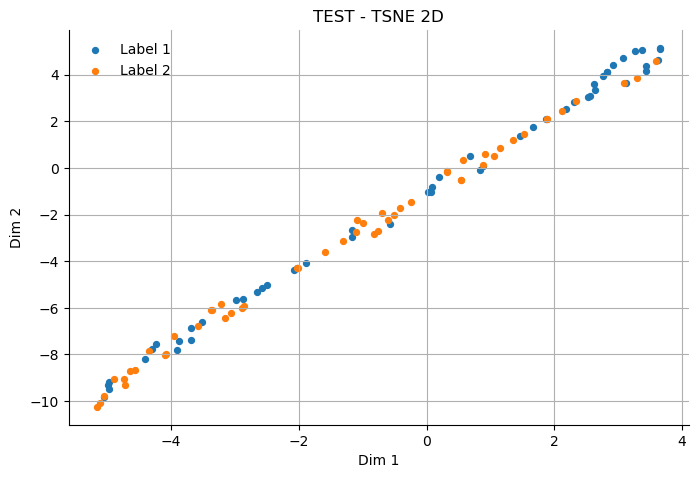

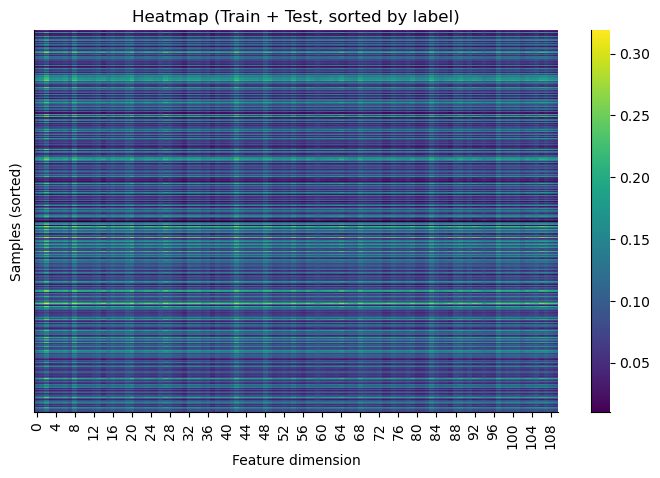

In [26]:
# Visualize best result
for split in ['train', 'test']:
    X = best_result[f"{split}_features"]
    y = best_result[f"{split}_labels"]

    for method in ['pca', 'tsne']:
        for dims in [2]:
            visualize_dim_reduction(X, y, method=method, dims=dims, split_name=split)

visualize_heatmap(
    best_result["train_features"], best_result["train_labels"],
    best_result["test_features"], best_result["test_labels"]
)

### 6. Bootstrap stability

To estimate stability, we repeat:
- bootstrap resampling of samples (0.9 ratio with replacement)
- split into train/val/test
- train BDAE (one setting)
- extract fused features
- evaluate SVM accuracy

We report mean/std/95% CI and show a boxplot + histogram.

For demo: keep `n_bootstrap` small.

In [27]:
# Load data
print("Data loaded.")
print("Neural data:", neural_data.shape)
print("Behavior data:", behavior_data.shape)
print("Labels:", labels.shape)

Data loaded.
Neural data: (516, 64)
Behavior data: (516, 4)
Labels: (516,)


In [28]:
# config (for demo set boostrap number to 5)
n_bootstrap = 5
batch_size = 50
n_iter_list = [50]
hidden_units_list = [110]
epochs_list = [1000]
learning_rate = 0.01

output_dir = './bootstrap_feature_fusion_noise0.1_fm'
os.makedirs(output_dir, exist_ok=True)

for boot in range(n_bootstrap):
    print(f"\n==== Bootstrap Round {boot+1}/{n_bootstrap} ====")
    
    subsample_ratio = 0.9
    subsample_size = int(neural_data.shape[0] * subsample_ratio)
    idx = np.random.choice(np.arange(neural_data.shape[0]), size=subsample_size, replace=True)
    Xn, Xb, y = neural_data[idx], behavior_data[idx], labels[idx]

    X_all = np.hstack([Xn, Xb])
    X_temp, X_test, y_temp, y_test = train_test_split(X_all, y, test_size=0.2, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

    n = Xn.shape[1]
    Xn_train, Xb_train = X_train[:, :n], X_train[:, n:]
    Xn_val, Xb_val = X_val[:, :n], X_val[:, n:]
    Xn_test, Xb_test = X_test[:, :n], X_test[:, n:]

    for n_iter in n_iter_list:
        for h in hidden_units_list:
            for epochs in epochs_list:
                try:
                    print(f"\n[BOOT {boot+1}] h={h} | n_iter={n_iter} | epochs={epochs}")
                    
                    rbm1 = BernoulliRBM(n_components=h, batch_size=batch_size, n_iter=n_iter, learning_rate=learning_rate)
                    rbm2 = BernoulliRBM(n_components=h, batch_size=batch_size, n_iter=n_iter, learning_rate=learning_rate)
                    rbm3 = BernoulliRBM(n_components=h, batch_size=batch_size, n_iter=n_iter, learning_rate=learning_rate)

                    rbm1.fit(Xn_train)
                    rbm2.fit(Xb_train)
                    hidden_neural = rbm1.transform(Xn_train)
                    hidden_behavior = rbm2.transform(Xb_train)
                    rbm3.fit(np.hstack([hidden_neural, hidden_behavior]))

                    def get_neural_part(t): return t[:, :h]
                    def get_behavior_part(t): return t[:, h:]

                    x_input = Input(shape=(Xn.shape[1],))
                    y_input = Input(shape=(Xb.shape[1],))

                    x_hidden = Dense(h, activation='sigmoid', name='x_hidden')(x_input)
                    y_hidden = Dense(h, activation='sigmoid', name='y_hidden')(y_input)

                    merge_xy = Concatenate()([x_hidden, y_hidden])
                    feature_layer = Dense(h, activation='sigmoid', name='merged')(merge_xy)
                    feature_layer = Dropout(0.2)(feature_layer)

                    merge_xy_t = Dense(2*h, activation='sigmoid', name='merge_t')(feature_layer)
                    x_hidden_t = Lambda(get_neural_part)(merge_xy_t)
                    y_hidden_t = Lambda(get_behavior_part)(merge_xy_t)

                    x_recon = Dense(Xn.shape[1], activation='sigmoid', name='x_recon')(x_hidden_t)
                    y_recon = Dense(Xb.shape[1], activation='sigmoid', name='y_recon')(y_hidden_t)

                    model = Model(inputs=[x_input, y_input], outputs=[x_recon, y_recon])

                    model.get_layer('x_hidden').set_weights([rbm1.components_.T, rbm1.intercept_hidden_])
                    model.get_layer('y_hidden').set_weights([rbm2.components_.T, rbm2.intercept_hidden_])
                    model.get_layer('merged').set_weights([rbm3.components_.T, rbm3.intercept_hidden_])
                    model.get_layer('merge_t').set_weights([rbm3.components_, rbm3.intercept_visible_])
                    model.get_layer('x_recon').set_weights([rbm1.components_, rbm1.intercept_visible_])
                    model.get_layer('y_recon').set_weights([rbm2.components_, rbm2.intercept_visible_])

                    model.compile(optimizer=RMSprop(lr=learning_rate), loss='mean_squared_error')

                    es = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
                    model.fit([Xn_train, Xb_train], [Xn_train, Xb_train],
                              validation_data=([Xn_val, Xb_val], [Xn_val, Xb_val]),
                              epochs=epochs, batch_size=batch_size, verbose=0, callbacks=[es])

                    feature_fn = K.function([model.input[0], model.input[1]], [model.get_layer("merged").output])
                    feat_train = feature_fn([Xn_train, Xb_train])[0]
                    feat_val = feature_fn([Xn_val, Xb_val])[0]
                    feat_test = feature_fn([Xn_test, Xb_test])[0]

                    tag = f"boot{boot+1}_h{h}_iter{n_iter}_ep{epochs}.pkl"
                    boot_dir = os.path.join(output_dir, f"boot{boot+1}")
                    os.makedirs(boot_dir, exist_ok=True)
                    save_path = os.path.join(boot_dir, tag)

                    with open(save_path, 'wb') as f:
                        pickle.dump({
                            'train_features': feat_train,
                            'train_labels': y_train,
                            'val_features': feat_val,
                            'val_labels': y_val,
                            'test_features': feat_test,
                            'test_labels': y_test
                        }, f)

                    print(f"Saved: {save_path}")
                except Exception as e:
                    print(f"Failed: boot{boot+1}_h{h}_iter{n_iter}_ep{epochs}. Reason: {e}")

                K.clear_session()
                gc.collect()

print("All bootstrap rounds complete.")


==== Bootstrap Round 1/5 ====

[BOOT 1] h=110 | n_iter=50 | epochs=1000
Saved: ./bootstrap_feature_fusion_noise0.1_fm\boot1\boot1_h110_iter50_ep1000.pkl


==== Bootstrap Round 2/5 ====

[BOOT 2] h=110 | n_iter=50 | epochs=1000
Saved: ./bootstrap_feature_fusion_noise0.1_fm\boot2\boot2_h110_iter50_ep1000.pkl

==== Bootstrap Round 3/5 ====

[BOOT 3] h=110 | n_iter=50 | epochs=1000
Saved: ./bootstrap_feature_fusion_noise0.1_fm\boot3\boot3_h110_iter50_ep1000.pkl

==== Bootstrap Round 4/5 ====

[BOOT 4] h=110 | n_iter=50 | epochs=1000
Saved: ./bootstrap_feature_fusion_noise0.1_fm\boot4\boot4_h110_iter50_ep1000.pkl

==== Bootstrap Round 5/5 ====

[BOOT 5] h=110 | n_iter=50 | epochs=1000
Saved: ./bootstrap_feature_fusion_noise0.1_fm\boot5\boot5_h110_iter50_ep1000.pkl
All bootstrap rounds complete.



===== Bootstrap Stability Summary =====
N bootstraps : 100
Mean acc     : 0.690968
Std (ddof=1) : 0.064888
95% CI       : [0.678092, 0.703843]
Min / Max    : 0.505376 / 0.860215


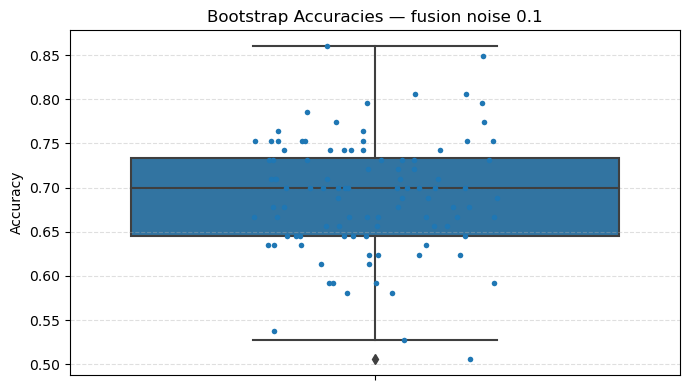

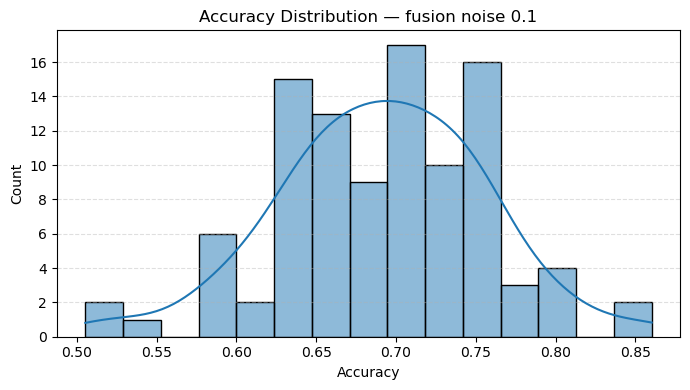

In [33]:
# Load
TASK_DIR = os.path.join(os.getcwd(), "bootstrap_feature_fusion_noise0.1")

def load_first_pkl(folder_path):
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".pkl")])
    if not files:
        return None, None
    path = os.path.join(folder_path, files[0])
    with open(path, "rb") as f:
        return pickle.load(f), files[0]

def svm_acc(data):
    X_tr = np.vstack([data["train_features"], data["val_features"]])
    y_tr = np.concatenate([data["train_labels"], data["val_labels"]])
    X_te, y_te = data["test_features"], data["test_labels"]

    clf = make_pipeline(
        StandardScaler(),
        LinearSVC(C=1.0, max_iter=10000, dual=False, random_state=42)
    )
    clf.fit(X_tr, y_tr)
    return accuracy_score(y_te, clf.predict(X_te))

# Main
boot_rounds = sorted([
    d for d in os.listdir(TASK_DIR)
    if os.path.isdir(os.path.join(TASK_DIR, d))
])

accs = []
for rd in boot_rounds:
    data, pkl_name = load_first_pkl(os.path.join(TASK_DIR, rd))
    if data is None:
        continue
    acc = svm_acc(data)
    accs.append(acc)
    # print(f"{rd}\t{pkl_name}\tacc={acc:.4f}")

accs = np.asarray(accs, dtype=float)
mean_acc = float(accs.mean())
std_acc  = float(accs.std(ddof=1)) if len(accs) > 1 else 0.0
min_acc, max_acc = float(accs.min()), float(accs.max())

if len(accs) > 1:
    ci_low, ci_high = stats.t.interval(
        0.95, len(accs) - 1, loc=mean_acc, scale=stats.sem(accs)
    )
else:
    ci_low, ci_high = mean_acc, mean_acc

print("\n===== Bootstrap Stability Summary =====")
print(f"N bootstraps : {len(accs)}")
print(f"Mean acc     : {mean_acc:.6f}")
print(f"Std (ddof=1) : {std_acc:.6f}")
print(f"95% CI       : [{ci_low:.6f}, {ci_high:.6f}]")
print(f"Min / Max    : {min_acc:.6f} / {max_acc:.6f}")

# Plot
plt.figure(figsize=(7, 4))
sns.boxplot(y=accs)
sns.stripplot(y=accs, jitter=0.2, size=4)
plt.title("Bootstrap Accuracies — fusion noise 0.1")
plt.ylabel("Accuracy")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(accs, kde=True, bins=15)
plt.title("Accuracy Distribution — fusion noise 0.1")
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()